In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

project_root = Path.cwd()
if not (project_root / "src").is_dir():
    project_root = project_root.parent

if not (project_root / "src").is_dir():
    raise FileNotFoundError

sys.path.insert(0, str(project_root))

from src.model import AirportSecurityModel

In [2]:
model = AirportSecurityModel(
    arrival_rate=0.4,
    queue_capacity=10,
    num_checkpoints=2,
    processing_time=4,
    simulation_steps=500
)

model.run()

results = model.get_results()

print(results)

{'average_waiting_time': np.float64(1.5436893203883495), 'maximum_waiting_time': np.int64(8), 'average_queue_length': np.float64(0.654), 'maximum_queue_length': np.int64(4), 'throughput': 206, 'external_waiting': 0}


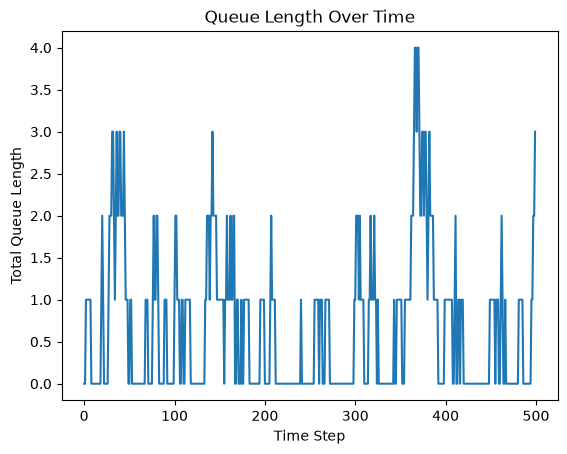

In [3]:
plt.plot(model.queue_length_history)

plt.xlabel("Time Step")
plt.ylabel("Total Queue Length")
plt.title("Queue Length Over Time")

plt.show()

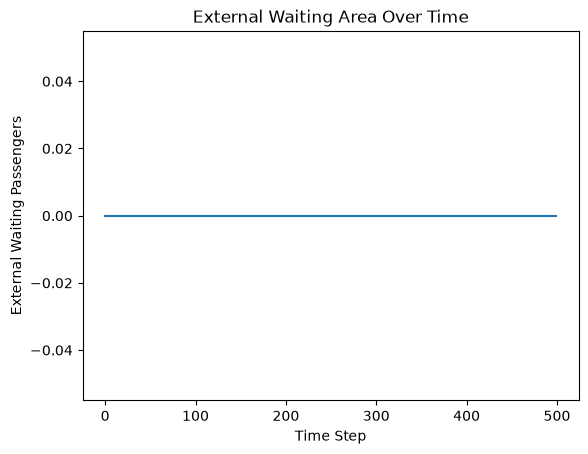

In [4]:
plt.plot(model.external_waiting_history)

plt.xlabel("Time Step")
plt.ylabel("External Waiting Passengers")
plt.title("External Waiting Area Over Time")

plt.show()

In [5]:
low_model = AirportSecurityModel(
    arrival_rate=0.1,
    queue_capacity=10,
    num_checkpoints=2,
    processing_time=4,
    simulation_steps=500
)

low_model.run()

print("Low arrival rate:")
print(low_model.get_results())

Low arrival rate:
{'average_waiting_time': np.float64(0.10204081632653061), 'maximum_waiting_time': np.int64(4), 'average_queue_length': np.float64(0.01), 'maximum_queue_length': np.int64(1), 'throughput': 49, 'external_waiting': 0}


In [6]:
high_model = AirportSecurityModel(
    arrival_rate=0.9,
    queue_capacity=10,
    num_checkpoints=2,
    processing_time=4,
    simulation_steps=500
)

high_model.run()

print("High arrival rate:")
print(high_model.get_results())

High arrival rate:
{'average_waiting_time': np.float64(111.61290322580645), 'maximum_waiting_time': np.int64(226), 'average_queue_length': np.float64(19.014), 'maximum_queue_length': np.int64(20), 'throughput': 248, 'external_waiting': 190}


### Reproducibility Check
Create two independent models with identical parameters and the same random seed, and verify that their results match.

In [7]:
def run_once(seed):
    model = AirportSecurityModel(
        arrival_rate=0.4,
        queue_capacity=10,
        num_checkpoints=2,
        processing_time=4,
        simulation_steps=500,
        seed=seed,
    )
    model.run()
    return model.get_results()


results_1 = run_once(seed=42)
results_2 = run_once(seed=42)

assert results_1 == results_2
print("Reproducibility check passed.")

Reproducibility check passed.


### Service Duration Validation
Verify that fixed, low-variation, and high-variation scenarios assign integer service durations within the expected bounds.

In [8]:
scenarios = {
    "Fixed": 0,
    "Low variation": 1,
    "High variation": 3,
}

for label, variation in scenarios.items():
    model = AirportSecurityModel(
        arrival_rate=0.4,
        queue_capacity=10,
        num_checkpoints=2,
        processing_time=4,
        processing_time_variation=variation,
        simulation_steps=500,
        seed=42,
    )
    model.run()

    durations = [
        passenger.processing_time
        for passenger in model.all_passengers
        if passenger.processing_time is not None
    ]

    assert durations, "No passengers started service."

    assert all(
        isinstance(duration, int)
        and 4 - variation <= duration <= 4 + variation
        for duration in durations
    ), f"{label}: invalid service duration."

    assert all(
        passenger.completion_time - passenger.service_start_time
        == passenger.processing_time
        for passenger in model.completed_passengers
    ), f"{label}: actual service time does not match assigned duration."

    print(
        f"{label}: validation passed. "
        f"Observed durations: {sorted(set(durations))}"
    )

Fixed: validation passed. Observed durations: [4]
Low variation: validation passed. Observed durations: [3, 4, 5]
High variation: validation passed. Observed durations: [1, 2, 3, 4, 5, 6, 7]
